# Unified MDTF/GFDL/NCAR Analysis Notebook Template

* More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)  

* To run this notebook, please set the correct kernel first. The commands to create a conda environment and make it accessible from Jupyter notebook (only need to do this once for each environment) are below:
```python
conda create -n esnb python=3.12
conda activate esnb
pip install esnb gcsfs
pip install ipykernel
python -m ipykernel install --user --name esnb
```

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2

import importlib
import collections
import io, sys, os
import yaml, json

# WMT add pathlib package
from pathlib import Path
import xarray as xr

# Set local environment variables
#os.environ["ESNB_LOG_LEVEL"] = "DEBUG"
os.environ['CODE_ROOT'] = '/scratch/leih/mdtf/MDTF-diagnostics'
os.environ['WORK_DIR'] = '/scratch/leih/mdtf/wkdir/MDTF_output/MCS_precip_buoy_stats'

## About the POD: MCS precipitation-buoyancy statistics

This POD provides diagnostics of tropical mesoscale convective systems (MCSs) and their thermodynamic environments,
informed by an empirical buoyancy measure (<em>B</em><sub>L</sub>). Specifically, these diagnostics are designed to evaluate model
performance in representing basic spatial-temporal characteristics of tropical MCSs and associated precipitation responses to the buoyancy measure under MCS and non-MCS conditions. The diagnostics include:

- Tropical-mean precipitation
- MCS frequency and its contribution to total precipitation
- Sensitivity of precipitation to individual buoyancy components, evaluated separately for MCS and non-MCS conditions
------------------------------------------
- A minimum of one year of data at 3-hourly temporal resolution is recommended to ensure a sufficient sample size of tropical MCSs.
- This POD is designed for models with relatively high horizontal resolution (≤ 0.5°). Conservative regridding is applied by default to ensure consistent comparisons between model outputs and the observational reference (GPM-IMERG + ERA5).
- Detailed descriptions of the POD are documeneted in "diagnostics/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst"
- There is a keyword "AdvUser" in this notebook for the benefit usage of advanced users.
-------------------------------------------

## Jupyter ESNB notebook POD settings
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD
- Set the runtime configurations
### [Section 2: Load Metadata from Catalog Files](#section2)
Two default options available (users can override)
- ESNB option (current default)
- Transition to Intake-ESM (led by Aparna)
### [Section 3: Diagnostics Computations](#section3)
- Step 1. MCS identification
- Step 2. Calculate MCS-associated Precipitation Statistics (frequency, contribution, etc)
- Step 3. Calculate the Lower-Tropospheric Buoyancy
- Step 4. Calculate MCS-associated Precipitation-Buoyancy Statistics
### [Section 4: Results Visualization](#section4)
- Plot annual precipitation
- Plot MCS frequency
- Plot MCS precipitation contribution
- Plot precipitation-buoyancy analysis
### [Section 5: More about this POD](#section5)
- [Check the .rst file](https://github.com/weiming9115/Working-Space/blob/master/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst)
- Placeholder

<a id='section1'> </a>
##  Section 1: Prepare POD Settings

In [2]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.getenv('CODE_ROOT')
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /scratch/leih/mdtf/MDTF-diagnostics


- If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [3]:
# Define a mode (leave "prod" for now)
mode = "interactive"

# Verbosity
verbose = True

### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- The user can change the time period, latitude range, number of workers
- AdvUser: feel free to define own parameters

In [4]:
if (mode == "interactive"):
  settings_dict = {
    "settings": {

        # ---------------------------------------------------
        # The pod_env_vars are used in the POD, not required by the MDTF framework
        # ---------------------------------------------------
        "pod_options": {
            # Options of running processes. Set "False" if this process has been completed before.
            # "experiment_name": "MPI-ESM1-2-HR_historical_r1i1p1f1.json",
            "run_mcs_identification": "True",
            "run_precip_statistics": "True",
            "plot_precip_statistics": "True",
            "run_buoyancy_calculation": "True",
            "run_buoyancy_statistics": "True",
            "plot_buoyancy_statistics": "True",

            # The time range of the MCS analysis. The MCS identification will generate files at
            # each timestep within this specified range, so consider 1-2 years to reduce computation time and save storage space
            "start_time": "20050101.0600",
            "end_time": "20060101.0000",
            # The latitude range:
            "latitude_max": 30,
            "latitude_min": -30,
            # The regridded resolution from the native resolution
            # precipitation statistics, buoyancy 2-D histograms (0.25, 0.5, or 1 degree)
            "regrid_res": 1,
            # The number of workers used for parallel computation. Recommended for high-resolution models (<= 0.5 degree)
            # Default is 8, which can be run on a general personal laptop.
            "num_workers": 8
        },

        # ---------------------------------------------------
        # The following settings are used by the MDTF framework
        # ---------------------------------------------------
        "runtime_requirements": {
            "python3": None,  # None means use the default python version of the MDTF framework
        },
        "driver": "mdtf.esnbtest.ipynb",
        "long_name": "Wei-Ming Tsai's MCS precipitation-buoyancy diagnostic",
        "convention": "cmip",
        "description": "Wei-Ming Tsai's MCS precipitation-buoyancy diagnostic",
    },
    "dimensions": {
        "lat": {
                "standard_name": "latitude",
                "units": "degrees_north",
                "axis": "Y"
            },
        "lon": {
                "standard_name": "longitude",
                "units": "degrees_east",
                "axis": "X"
            },
        "plev": {
                "standard_name": "air_pressure",
                "units": "hPa",
                "positive": "down",
                "axis": "Z"
            },
        "time": {"standard_name": "time"}
    },

    # In this section, user can describe what model data the diagnostic uses. Add one
    # list entry (the section in curly braces) for each variable, separated by commas.
    "varlist" : {
        # Variable identifier. A variable with this name will be set to
        # what the corresponding field is called in the model being analyzed.
        "pr": {
                "standard_name" : "precipitation_flux",
                "requirement": "required",
                "realm": "atmos",
                "units": "kg m-2 s-1",
                "frequency" : "6hr",
                "dimensions": ["time", "lat", "lon"]
        },
        "rlut": {
                "standard_name" : "toa_outgoing_longwave_flux",
                "requirement": "required",
                "realm": "atmos",
                "units": "W m-2",
                "frequency" : "6hr",
                "dimensions": ["time", "lat", "lon"]
        },
        "ta": {
                "standard_name": "air_temperature",
                "requirement": "required",
                "realm": "atmos",
                "units": "K",
                "frequency" : "6hr",
                "dimensions" : ["time", "plev", "lat", "lon"]
            },
        "hus": {
                "standard_name": "specific_humidity",
                "requirement": "required",
                "realm": "atmos",
                "frequency" : "6hr",
                "units": "kg/kg",
                "dimensions" : ["time", "plev", "lat", "lon"]
            }
    },
    }
# batch mode: running mdtf executable from the command line, read settings from the settings.jsonc file
else:
    # Specify the path to the JSONC file
    settings_file_path = os.path.join(module_path, "diagnostics/MCS_precip_buoy_stats/settings.jsonc")

    try:
        # Open and read the JSONC file using MDTF framework's json_utils
        settings_dict = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# Pretty-print the loaded JSON data
# print(json_utils.pretty_print_json(settings_dict))

### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file
- case_info stores the information needed to generate the diagnostics
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a runtime_config.yml file

In [5]:
if (mode == "interactive"):
    # If running in interactive mode, input case settings are made here. Otherwise they are read from the input settings file,
    # which should contain everything. Extra key value pairs can be added in a later cell.
    case_info = {
     "case_list": {
            "MPI-ESM1-2-HR_historical_r1i1p1f1_gn": # this is the case/model name
            {
                "convention": "CMIP",
                "enddate": "20060101000000",
                "model": "MPI-ESM1-2-HR",
                "startdate": "20050101060000",
                'frequency': '6hr'
            }
        },
        "DATA_CATALOG": "/scratch/leih/mdtf/catalogs/MPI-ESM1-2-HR_historical_r11i1p1f1.esnb.json",
        "OBS_DATA_ROOT": "/scratch/leih/mdtf/inputdata/obs_data",
        "WORK_DIR": "/scratch/leih/mdtf/wkdir",
        "OUTPUT_DIR": "/scratch/leih/mdtf/wkdir", #leaving blank will use the WORK_DIR
        "conda_env_root": "/scratch/leih/anaconda3/envs",
        "conda_root": "/scratch/leih/anaconda3",
        "large_file": False,
        "make_multicase_figure_html": False,
        "make_variab_tar": False,
        "micromamba_exe": "",
        "overwrite": True,
        "pod_list": ["MCS_precip_buoy_stats"],
        "run_pp": True,
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True,
        "user_pp_scripts": [""]
    }
else:
    # Receive a dictionary of case information from the framework.
    # This needs to be passed from the MDTF framework (will be an argument to the command line call)"
    case_input_file =  os.path.join(module_path, "runtime_config.MCS.yml")
    print("reading default settings from {case_input_file}")

    assert os.path.isfile(case_input_file), f"case environment file not found"
    with open(case_input_file, 'r') as stream:
        try:
            case_info = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

- The cell below defines a dictionary of variable name mappings. These will be used to rename the variables if needed, but this is optional.

In [6]:
mapping = {
    "zg": "Z500",
}

<a id="section2"> </a>
## Section 2: Load Metadata from Catalog Files

In [8]:
# Import intake-esm library
import intake, intake_esm

### Initialize the diagnostic and an MDTF case

In [9]:
cat = intake.open_esm_datastore(case_info['DATA_CATALOG'])

In [10]:
cat

,unique
activity_id,1
assoc_files,1
institution_id,1
member_id,1
realm,1
variable_id,4
table_id,3
source_id,1
source_type,1
cell_methods,1


In [11]:
settings_dict['varlist'].keys()

dict_keys(['pr', 'rlut', 'ta', 'hus'])

In [12]:
cat_subset = cat.search(
    variable_id=settings_dict['varlist'].keys(),
    #variable_id='hus',
    frequency='6hr',
)

In [13]:
print(cat_subset.keys())

['CMIP.MPI-M.MPI-ESM1-2-HR.historical.6hr.r1i1p1f1.3hr.gn.atmos.r1i1p1f1', 'CMIP.MPI-M.MPI-ESM1-2-HR.historical.6hr.r1i1p1f1.6hrPlevPt.gn.atmos.r1i1p1f1', 'CMIP.MPI-M.MPI-ESM1-2-HR.historical.6hr.r1i1p1f1.E3hr.gn.atmos.r1i1p1f1']


In [14]:
cat_subset

,unique
activity_id,1
assoc_files,1
institution_id,1
member_id,1
realm,1
variable_id,4
table_id,3
source_id,1
source_type,1
cell_methods,1


In [15]:
print(cat_subset.df["path"].values)

<ArrowExtensionArray>
[  '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.pr.6hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.rlut.6hr.nc',
  '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010600-201001010000.hus.6hr.nc',
   '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010600-201001010000.ta.6hr.nc']
Length: 4, dtype: large_string[pyarrow]


In [16]:
dset_dict = {}

for var in settings_dict['varlist'].keys():
    row = cat_subset.df[cat_subset.df["variable_id"] == var].iloc[0]
    path = row["path"]

    ds = xr.open_dataset(
        path,
        chunks={"time": 1},
        decode_times=True,
    )
    # Select only a time range
    ds = ds.sel(time=slice('2005-01-01', '2005-12-31'))
    dset_dict[var] = ds[var]

In [17]:
dset_dict

{'pr': <xarray.DataArray 'pr' (time: 1460, lat: 192, lon: 384)> Size: 431MB
 dask.array<getitem, shape=(1460, 192, 384), dtype=float32, chunksize=(1, 192, 384), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 12kB 2005-01-01 ... 2005-12-31T18:00:00
   * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
   * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
 Attributes:
     standard_name:  precipitation_flux
     long_name:      Precipitation
     comment:        includes both liquid and solid phases
     units:          kg m-2 s-1
     original_name:  pr
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     history:        2019-08-25T11:31:14Z altered by CMOR: replaced missing va...,
 'rlut': <xarray.DataArray 'rlut' (time: 1460, lat: 192, lon: 384)> Size: 431MB
 dask.array<getitem, shape=(1460, 192, 384), dtype=float32, chunksize=(1, 192, 384), chunktype=numpy.ndarray>
 Coordinates:


<a id='section3'> </a>
## Section 3: Diagnostics Computations

In [18]:
pod_dir = Path(os.getenv('CODE_ROOT')) / f'diagnostics/MCS_precip_buoy_stats'
utils_dir = pod_dir / f'mcs_utils'
# Add utils to the system path to import modules saved under "/mcs_utils"
sys.path.append(str(utils_dir))

In [ ]:
# ****NOTE****** numba is required for the POD. Install that unde the "esnb" enviroment
#!pip install numba
#!pip install json5
#!pip install cartopy
#!pip install xesmf
#!conda install -c conda-forge esmpy -y
#!pip install numpy==1.26.4 # The original is 2.4.2, which is not compatible with esmpy...

### Step 1. MCS identification
Identify 2-D MCS masks based on a "snapshot-based" approach using thresholds similar to PyFLEXTRKR (see ./doc/MCS_precip_buoy_stats.rst).

Users can skip this step if they have alternative data (e.g., tracked MCSs from trackers).
 1. In this case, set "run_mcs_identification" = False and make sure that you
    create the corresponding directory "MDTF_output/model/netCDF/MCS_identifiers/" ahead
    and save the data following the directory structure described in "MCS_precip_buoy_stats.rst"
    before running "./mdtf -f /tempelate/runtime_config.yml"

 2. Three variables are required in a single MCS data file:
    - "mcs_flag": 2-D MCS binary mask
    - "precipitation": precipitation rate (mm/hr)
    - "tb": brightness temperature (K)

 3. Output directory: `$WORK_DIR/model/netCDF/MCS_identifiers`
 4. AdvUser: There are additional parameters in `dask_write_cloudid_PyFLEXTRKR()` within `process_PyFLEXTRKR_MCSmask_writeout_parallel.py` for MCS identification, advanced users can adjust them

In [20]:
from process_PyFLEXTRKR_MCSmask_writeout_parallel import dask_write_cloudid_PyFLEXTRKR

if settings_dict['settings']['pod_options']['run_mcs_identification']:
    start_year = int(str(settings_dict['settings']['pod_options']['start_time'])[:4])
    end_year = int(str(settings_dict['settings']['pod_options']['end_time'])[:4])
    print(start_year, end_year)
    # Create "MCS_identifiers" directory and start identifying MCSs
    # Subdaily outputs will be saved under "MCS_identifiers/$year"
    for year in range(start_year, end_year + 1):
        #print(year)
        dask_write_cloudid_PyFLEXTRKR(xr.Dataset({'pr': dset_dict['pr'], 'rlut': dset_dict['rlut']}), year)

2005 2006
Loading data into memory...
Pre-calculating TB and Pr...
Processing 1460 timesteps...
Done.
Loading data into memory...
Pre-calculating TB and Pr...
Processing 0 timesteps...
Done.


### Step 2. Calculate MCS-associated Precipitation Statistics
 - Requried steps: STEP 1
  1. This step writes out diagnostics outputs: MCS frequency, mean precip, accumulative precip, accumulative MCS precip, ... etc.
  2. Output directory: `$WORK_DIR/model/netCDF/stats`  
     Output file name: `precip_mcsstats_regridded_monthly.$YEAR.nc`
  3. NOTE: The `.main()` cannot be called inside the notebook since it uses multiprocessing, thus the function needs to be called using `subprocess.run()`.

In [21]:
import process_prmcs_stats_writeout, subprocess

if settings_dict['settings']['pod_options']['run_precip_statistics']:
    subprocess.run([sys.executable, str(utils_dir / 'process_prmcs_stats_writeout.py')], check=True)

### Step 3. Calculate the Lower-Tropospheric Buoyancy
- Required steps: N/A

1. This step calculates the two-layer buoyancy components: BL,CAPE and BL,SUBSAT (see ./doc/MCS_precip_buoy_stats.rst)
2. Output directory:  `$WORK_DIR/model/netCDF/layer_averaged_thetae`

##### Note: Generated files ~ 500 M per year given 1-deg. and 6-hourly resolutions: Users should be aware of available storage before running the POD.

In [22]:
xr.Dataset({'hus': dset_dict['hus'], 'ta': dset_dict['ta']})

<xarray.Dataset> Size: 24GB
Dimensions:  (time: 1459, plev: 28, lat: 192, lon: 384)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2005-01-01T06:00:00 ... 2005-12-31T18...
  * plev     (plev) float64 224B 1e+05 9.75e+04 9.5e+04 ... 1.25e+04 1e+04 5e+03
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Data variables:
    hus      (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 14, 96, 192), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 14, 96, 192), meta=np.ndarray>

In [24]:
from process_layer_thetae_writeout import process_thetae_layers

if settings_dict['settings']['pod_options']['run_precip_statistics']:

    thetae_dir = Path(os.getenv('WORK_DIR'))/'model/netCDF/layer_averaged_thetae/'
    thetae_dir.mkdir(parents=True, exist_ok=True)
    process_thetae_layers(xr.Dataset({'hus': dset_dict['hus'], 'ta': dset_dict['ta']}), thetae_dir, ntime=None,
                          num_workers=settings_dict['settings']['pod_options']['num_workers'])

Starting parallel processing for 1459 steps...
Merging into 12 monthly files...
Completed: layer_averaged_thetae_buoyancy.2005.01.nc
Completed: layer_averaged_thetae_buoyancy.2005.02.nc
Completed: layer_averaged_thetae_buoyancy.2005.03.nc
Completed: layer_averaged_thetae_buoyancy.2005.04.nc
Completed: layer_averaged_thetae_buoyancy.2005.05.nc
Completed: layer_averaged_thetae_buoyancy.2005.06.nc
Completed: layer_averaged_thetae_buoyancy.2005.07.nc
Completed: layer_averaged_thetae_buoyancy.2005.08.nc
Completed: layer_averaged_thetae_buoyancy.2005.09.nc
Completed: layer_averaged_thetae_buoyancy.2005.10.nc
Completed: layer_averaged_thetae_buoyancy.2005.11.nc
Completed: layer_averaged_thetae_buoyancy.2005.12.nc
Total time elapsed: 71.74s


<a id='section4'> </a>
## Section 4: Results Visualization

### Plot precipitaiton and MCS-associated maps
- Requried steps: STEP 2
1. This step generates diagnostics figures
2. Output directory for the figures: `$WORK_DIR/fig`

<xarray.Dataset> Size: 25GB
Dimensions:  (time: 1460, lat: 192, lon: 384, plev: 28)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2005-01-01 ... 2005-12-31T18:00:00
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * plev     (plev) float64 224B 1e+05 9.75e+04 9.5e+04 ... 1.25e+04 1e+04 5e+03
Data variables:
    pr       (time, lat, lon) float32 431MB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    rlut     (time, lat, lon) float32 431MB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 14, 96, 192), meta=np.ndarray>
    hus      (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 14, 96, 192), meta=np.ndarray>
MPI-ESM1-2-HR
Combined figure saved as: /scratch/leih/mdtf/wkdir/MDTF_output/MCS_precip_buoy_stats/fig/precipitation_climate.MODvsOBS.png
Combined figure saved as: /scrat

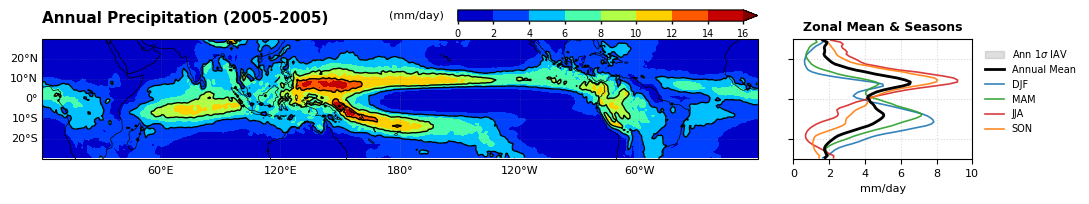

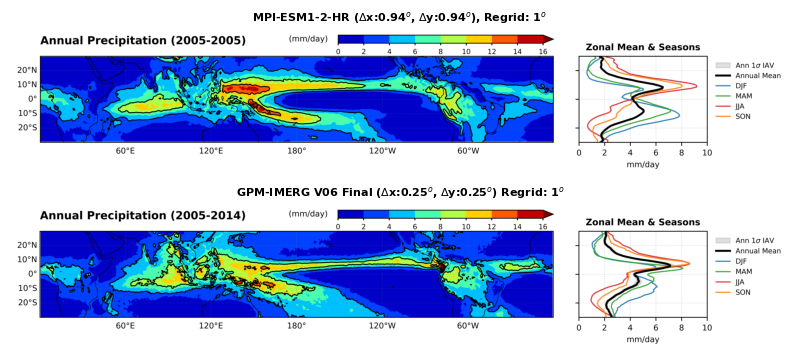

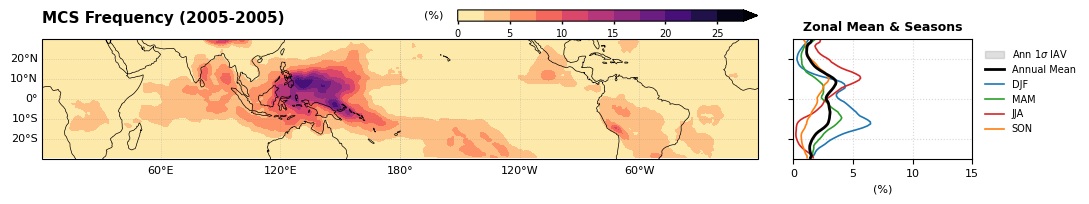

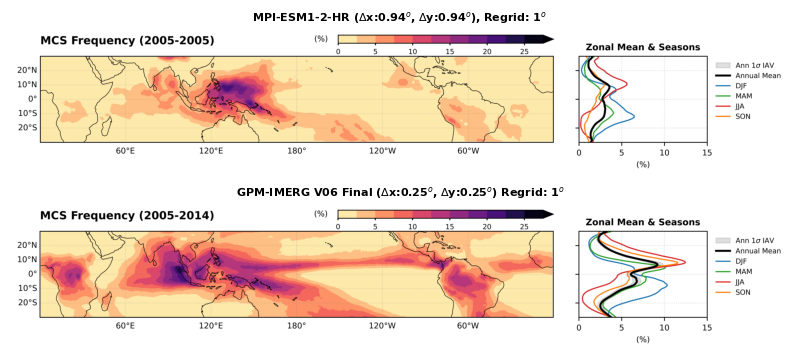

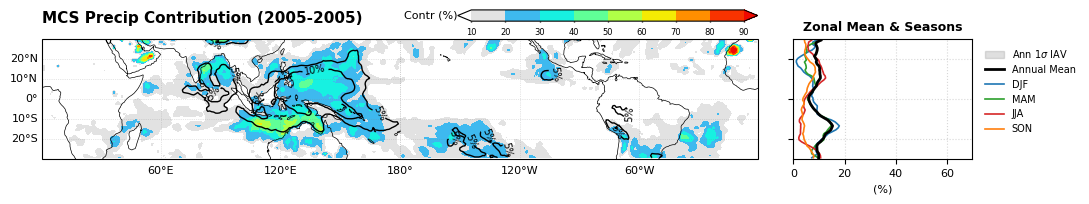

In [37]:
import plot_precip_stats

case_name = next(iter(case_info['case_list']))
model_id = case_info['case_list'][case_name]['model']

if settings_dict['settings']['pod_options']['plot_precip_statistics']:
    plot_precip_stats.main(ds_file=xr.Dataset(dset_dict), model_id=model_id)

<a id='section5'> </a>
## Section 5: More about this POD
- Detailed descriptions of the POD are documeneted in "diagnostics/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst" or click this [link](https://github.com/weiming9115/Working-Space/blob/master/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst).